[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/probabilistic-forecasting/blob/main/03-time-series-diffusion/post3_time_series_diffusion.ipynb)

# From a Gaussian Head to a Diffusion Head

**Companion notebook to:** [*Your Model's MSE Is Lying to You III: Time Series Diffusion*](https://towardsdatascience.com/your-models-mse-is-lying-to-you-iii-time-series-diffusion/)

Parts [I](https://github.com/wesmail/probabilistic-forecasting/tree/main/01-point-vs-probabilistic) and [II](https://github.com/wesmail/probabilistic-forecasting/tree/main/02-probabilistic-autoregressive-forecasting) gave the model an honest per-step uncertainty and a way to carry it forward. Both still assume that the next value is drawn from a **single Gaussian**. That assumption breaks when the future has more than one peak, for example a ball balanced on a ridge, which can roll left or right, and will not stay at the mean.

This notebook is the hands-on companion to [Part III](https://towardsdatascience.com/your-models-mse-is-lying-to-you-iii-time-series-diffusion/). The article explains the motivation and derives the math; here the same ideas appear in code, in the same order, so you can read the two side by side. Theory comes first (on a tiny two-bump example); the forecasting dataset comes last.

**What we will do**

| Notebook part | What happens | Article sections |
|---|---|---|
| 1 | See a forecast with the right mean and variance but the wrong shape, then repair it with $K$ bell curves and with infinitely many | 1–3 |
| 2 | Add noise step by step, and remove it again without any neural network | 4, 5, 7 |
| 3 | Train our first diffusion model, on a single number | 6, 8 |
| 4 | Build the dataset: a ball in a landscape with two wells | 9 |
| 5 | Build two forecasters that differ only in their head, and train them | 9 |
| 6 | Roll them out as in Part II and compare them with the true answer | 10 |

**What you need.** Python with `numpy`, `torch`, and `matplotlib`. No GPU is needed, everything is small enough to run on a laptop CPU in a few minutes (the diffusion rollout is the slowest cell, about one to two minutes).

**How to use it.** Run the cells from top to bottom. Every figure is also saved into a folder called `figures/`.

**Two kinds of time.** In this series $t$ is the time index of the signal and $T$ the length of the context. The *noise level* of the diffusion model is therefore called $n$ here (`n` in the code), and it runs from $0$ (clean) to $N$ (pure noise, `N_STEPS` in the code).


In [1]:
import math
import os
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Fix the random seeds, so that every run of the notebook gives the same numbers.
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

# One colour per "player", used in every figure.
C_TRUE  = "#52514e"   # grey : the true answer
C_GAUSS = "#2a78d6"   # blue : Gaussian head
C_DIFF  = "#1baf7a"   # green: diffusion head

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "legend.fontsize": 9, "legend.frameon": False,
})

# Every figure is saved here, so that the article can use it.
os.makedirs("figures", exist_ok=True)


def show(name):
    """Save the current figure as figures/<name>.png and display it."""
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Part 1 — Right mean, right variance, wrong shape

We start with the thought experiment of the article. The next value $y$ is close to $+1$ half of the time and close to $-1$ the other half of the time, with a small spread of $0.1$ around each.

The best that a Gaussian head (the two-head model of Parts I and II) can do is to match the mean and the standard deviation of the data. The cell below creates the data, computes that best Gaussian, and counts how often each of them produces a value in the middle region $|y| < 0.5$.


best Gaussian head:  mu = -0.001   sigma = 1.005
share of values with |y| < 0.5:   truth 0.0%   Gaussian head 37.9%


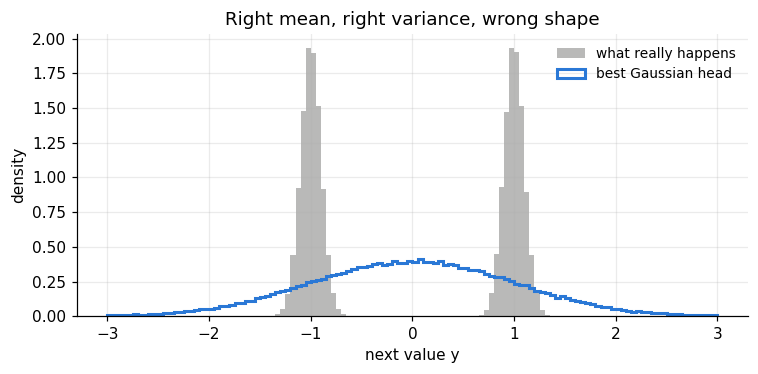

In [2]:
rng = np.random.default_rng(0)
n_points = 100_000

# What really happens: the next value is near -1 or near +1, each half of the time.
bump = rng.choice([-1.0, 1.0], size=n_points)
y_two_bumps = bump + 0.1 * rng.standard_normal(n_points)

# The best a Gaussian head can do: match the mean and the standard deviation of the data.
mu = y_two_bumps.mean()
sigma = y_two_bumps.std()
y_gauss = mu + sigma * rng.standard_normal(n_points)      # samples from that Gaussian

share_truth = np.mean(np.abs(y_two_bumps) < 0.5)
share_gauss = np.mean(np.abs(y_gauss) < 0.5)
print(f"best Gaussian head:  mu = {mu:+.3f}   sigma = {sigma:.3f}")
print(f"share of values with |y| < 0.5:   truth {share_truth:.1%}   Gaussian head {share_gauss:.1%}")

plt.figure(figsize=(7, 3.5))
bins = np.linspace(-3, 3, 121)
plt.hist(y_two_bumps, bins, density=True, color=C_TRUE, alpha=0.4, label="what really happens")
plt.hist(y_gauss, bins, density=True, histtype="step", lw=2, color=C_GAUSS, label="best Gaussian head")
plt.xlabel("next value y")
plt.ylabel("density")
plt.title("Right mean, right variance, wrong shape")
plt.legend()
show("fig1_right_moments_wrong_shape")

You should see $\mu \approx 0$ and $\sigma \approx 1.005$, and about 38 % of the Gaussian samples in a region where the truth has practically none. The Gaussian puts its peak exactly where reality never goes.

### From one bell curve to K, and from K to infinitely many

The article climbs towards diffusion in two steps (Sections 2 and 3), and the next cell shows both.

* **K bell curves (a mixture).** A sample is drawn in two stages: pick one of the K bell curves, then draw from it. With K = 2 bell curves at $-1$ and $+1$ we can describe the two bumps exactly. The choice of the bell curve is a **hidden variable**, since it never appears in the data.
* **Infinitely many bell curves (a continuous mixture).** The hidden variable becomes a continuous number $z \sim \mathcal{N}(0, 1)$, and a function $\mu(z)$ gives the centre of the bell curve for every $z$. A sample is again drawn in two stages: draw $z$, then draw $y = \mu(z) + 0.1 \cdot \text{noise}$. Nobody has to choose K any more.

continuous mixture: share of values with |y| < 0.5 = 5.6%   (the best single Gaussian had about 38 %)


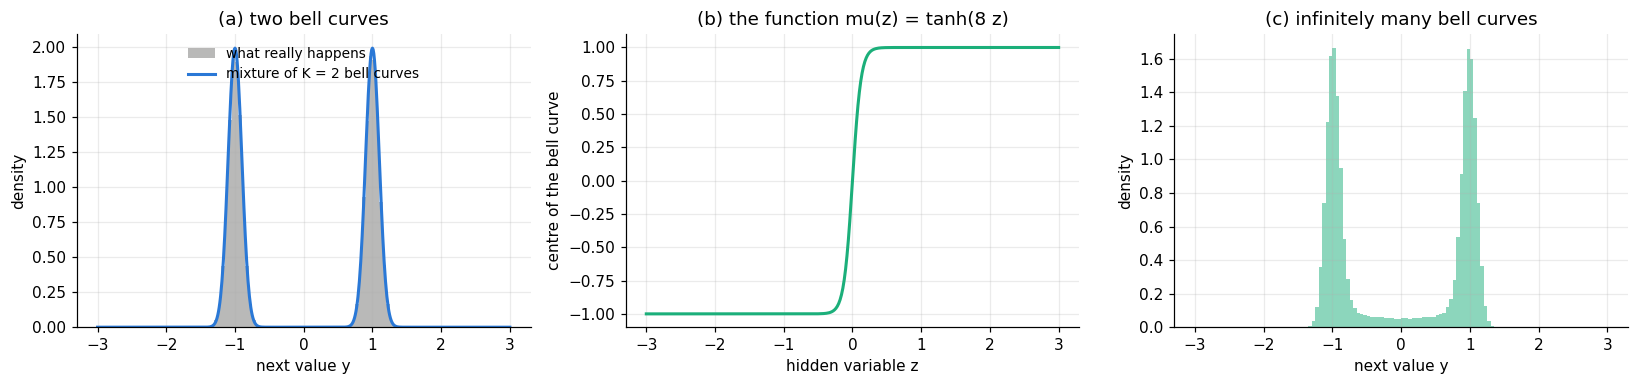

In [3]:
def bell(x, mean, std):
    """The density of a Gaussian N(mean, std^2) at the points x."""
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


# --- K = 2 bell curves: the density of the mixture ---
grid = np.linspace(-3, 3, 601)
mixture_density = 0.5 * bell(grid, -1.0, 0.1) + 0.5 * bell(grid, +1.0, 0.1)


# --- infinitely many bell curves: a hidden number z, a function mu(z), and a little noise ---
def mu_of_z(z):
    """The centre of the bell curve that belongs to the hidden value z."""
    return np.tanh(8 * z)


z = rng.standard_normal(n_points)                                 # stage 1: draw the hidden variable
y_continuous = mu_of_z(z) + 0.1 * rng.standard_normal(n_points)   # stage 2: draw from the bell curve it selects

share_middle = np.mean(np.abs(y_continuous) < 0.5)
print(f"continuous mixture: share of values with |y| < 0.5 = {share_middle:.1%}   (the best single Gaussian had about 38 %)")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
bins = np.linspace(-3, 3, 121)

axes[0].hist(y_two_bumps, bins, density=True, color=C_TRUE, alpha=0.4, label="what really happens")
axes[0].plot(grid, mixture_density, color=C_GAUSS, lw=2, label="mixture of K = 2 bell curves")
axes[0].set_title("(a) two bell curves")
axes[0].set_xlabel("next value y")
axes[0].set_ylabel("density")
axes[0].legend(loc="upper center")

z_grid = np.linspace(-3, 3, 301)
axes[1].plot(z_grid, mu_of_z(z_grid), color=C_DIFF, lw=2)
axes[1].set_title("(b) the function mu(z) = tanh(8 z)")
axes[1].set_xlabel("hidden variable z")
axes[1].set_ylabel("centre of the bell curve")

axes[2].hist(y_continuous, bins, density=True, color=C_DIFF, alpha=0.5)
axes[2].set_title("(c) infinitely many bell curves")
axes[2].set_xlabel("next value y")
axes[2].set_ylabel("density")

show("fig2_one_to_many")

In panel (c), the only randomness that went in was Gaussian (the hidden $z$ and the small noise), and what came out has two bumps. The shape is entirely the work of the function $\mu(z)$. This is the idea we keep: Gaussian noise in, a nonlinear function, any shape out. The difficulty, explained in Section 3.3 of the article, is that such a model is hard to train, because for an observed value we do not know which hidden $z$ produced it. A diffusion model avoids this by building its hidden variables itself, out of the data, by adding noise.

# Part 2 — Adding noise, and removing it

### The forward process

The forward process adds a little noise at every step (article, Section 4.2):

$$y_n = \sqrt{1 - \beta_n}\;y_{n-1} + \sqrt{\beta_n}\;\varepsilon_n$$

Thanks to the **jump formula** (article, Section 4.5), we never have to walk through the steps one by one, because we can go from a clean value $y_0$ to any noise level $n$ in one line:

$$y_n = \sqrt{\bar\alpha_n}\;y_0 + \sqrt{1 - \bar\alpha_n}\;\varepsilon$$

Here $\bar\alpha_n$ is the share of the signal that survives after $n$ steps. It starts at 1 (clean) and ends close to 0 (pure noise). The function `cosine_alphabar` creates this curve with the cosine schedule (article, Section 4.6), the individual steps follow from $\beta_n = 1 - \bar\alpha_n / \bar\alpha_{n-1}$, and `add_noise` is the jump formula.

The cell also checks the jump formula: it noises the two-bump data of Part 1 once with 20 small steps and once with a single jump to level 20, and compares the results.


first three betas: [0.0017 0.0037 0.0056]   last three betas: [0.555 0.75  0.897]
20 small steps:  mean -0.003   variance 1.007   share with |y| < 0.5: 29.1%
one jump      :  mean -0.002   variance 1.007   share with |y| < 0.5: 29.2%


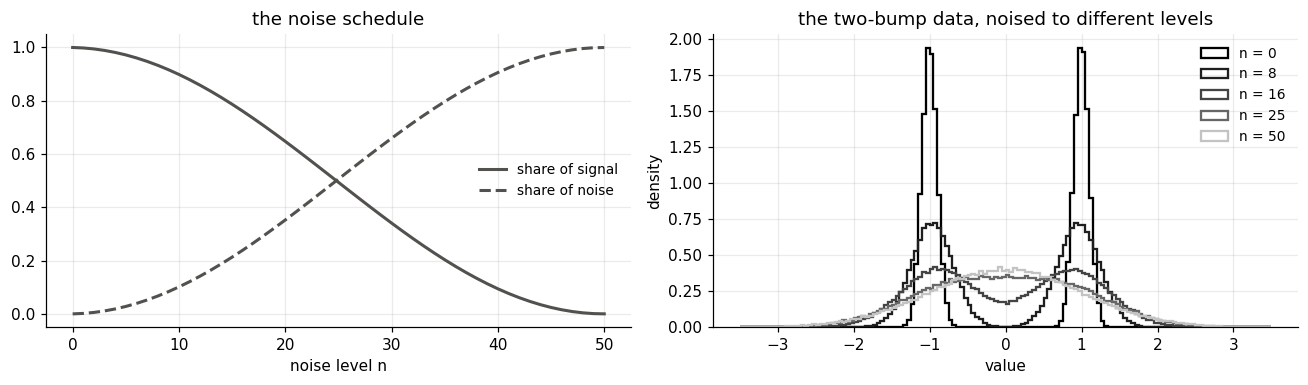

In [4]:
N_STEPS = 50     # number of noise levels N


def cosine_alphabar(n_steps, s=0.008):
    """Signal share for n = 0 .. n_steps: alphabar[0] = 1 (clean), alphabar[n_steps] close to 0 (pure noise)."""
    n = torch.arange(n_steps + 1, dtype=torch.float32)
    f = torch.cos((n / n_steps + s) / (1 + s) * math.pi / 2) ** 2
    return (f / f[0]).clamp(min=1e-4)


alphabar = cosine_alphabar(N_STEPS)          # alphabar[n] for n = 0 .. N,  shape (N_STEPS + 1,)
beta = 1 - alphabar[1:] / alphabar[:-1]      # beta[n - 1] is beta_n,       shape (N_STEPS,)
print("first three betas:", beta[:3].numpy().round(4), "  last three betas:", beta[-3:].numpy().round(3))


def add_noise(y0, n):
    """The jump formula. y0: (B, 1) clean values, n: (B,) noise level of each row. Returns (y_n, eps)."""
    ab = alphabar[n].unsqueeze(-1)           # (B, 1)
    eps = torch.randn_like(y0)
    y_n = ab.sqrt() * y0 + (1 - ab).sqrt() * eps
    return y_n, eps


torch.manual_seed(0)
values = torch.tensor(y_two_bumps, dtype=torch.float32).unsqueeze(-1)    # the two-bump data of Part 1: (100000, 1)

# --- Check: 20 small steps give the same distribution as one jump to level 20 ---
y_steps = values.clone()
for n in range(1, 21):
    beta_n = beta[n - 1]
    y_steps = (1 - beta_n).sqrt() * y_steps + beta_n.sqrt() * torch.randn_like(y_steps)    # the one-step rule
y_jump, _ = add_noise(values, torch.full((len(values),), 20))                              # the jump formula

for name, y in [("20 small steps", y_steps), ("one jump      ", y_jump)]:
    middle = (y.abs() < 0.5).float().mean()
    print(f"{name}:  mean {y.mean():+.3f}   variance {y.var():.3f}   share with |y| < 0.5: {middle:.1%}")

# --- Figure: what the forward process does to the two-bump data ---
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

axes[0].plot(alphabar, color=C_TRUE, lw=2, label="share of signal")
axes[0].plot(1 - alphabar, color=C_TRUE, lw=2, ls="--", label="share of noise")
axes[0].set_xlabel("noise level n")
axes[0].set_title("the noise schedule")
axes[0].legend()

# five noise levels, from clean (n = 0) to pure noise (n = N_STEPS)
bins = np.linspace(-3.5, 3.5, 141)
for n in [0, N_STEPS // 6, N_STEPS // 3, N_STEPS // 2, N_STEPS]:
    level = torch.full((len(values),), n)                    # the same noise level for every row
    noisy, _ = add_noise(values, level)
    grey = plt.cm.Greys(0.35 + 0.65 * (1 - n / N_STEPS))     # darker = less noise
    axes[1].hist(noisy.flatten().numpy(), bins, density=True, histtype="step", lw=1.5,
                 color=grey, label=f"n = {n}")
axes[1].set_xlabel("value")
axes[1].set_ylabel("density")
axes[1].set_title("the two-bump data, noised to different levels")
axes[1].legend()

show("fig3_forward_process")

The two printed lines should agree: 20 small steps and one jump give the same distribution. In the figure, the right panel shows the two bumps of the data widening, sliding towards each other and merging into one bell curve. Generation will run this film backwards.

### The reverse process, without any neural network

To go back one step, from $y_n$ to $y_{n-1}$, we need a guess $\hat y_0$ of the clean value. With that guess, the reverse step is a small Gaussian step (article, Section 6, Step 3, part B, and Section 8):

$$\mu = \frac{\sqrt{\bar\alpha_{n-1}}\;\beta_n}{1 - \bar\alpha_n}\;\hat y_0 + \frac{\sqrt{\alpha_n}\,(1 - \bar\alpha_{n-1})}{1 - \bar\alpha_n}\;y_n, \qquad y_{n-1} = \mu + \tilde\sigma_n \cdot \text{noise}$$

Later a neural network will supply the guess. For two simple cases, however, the best possible guess $\mathbb{E}[y_0 \mid y_n]$ is known as a formula (article, Section 7.2), so we can run the whole reverse process with no network at all:

* if the data is **one Gaussian**, the best guess is a **straight line** in $y_n$;
* if the data is **two bumps**, the best guess is an **S-shaped curve** in $y_n$.

Both data distributions below have the same mean (0) and the same variance (1.01). Everything else is identical too: the same starting noise, the same sampler and the same schedule.

straight-line denoiser   mean +0.00   variance 0.92   share with |y| < 0.5: 39.8%
S-curve denoiser         mean -0.00   variance 1.00   share with |y| < 0.5: 0.0%


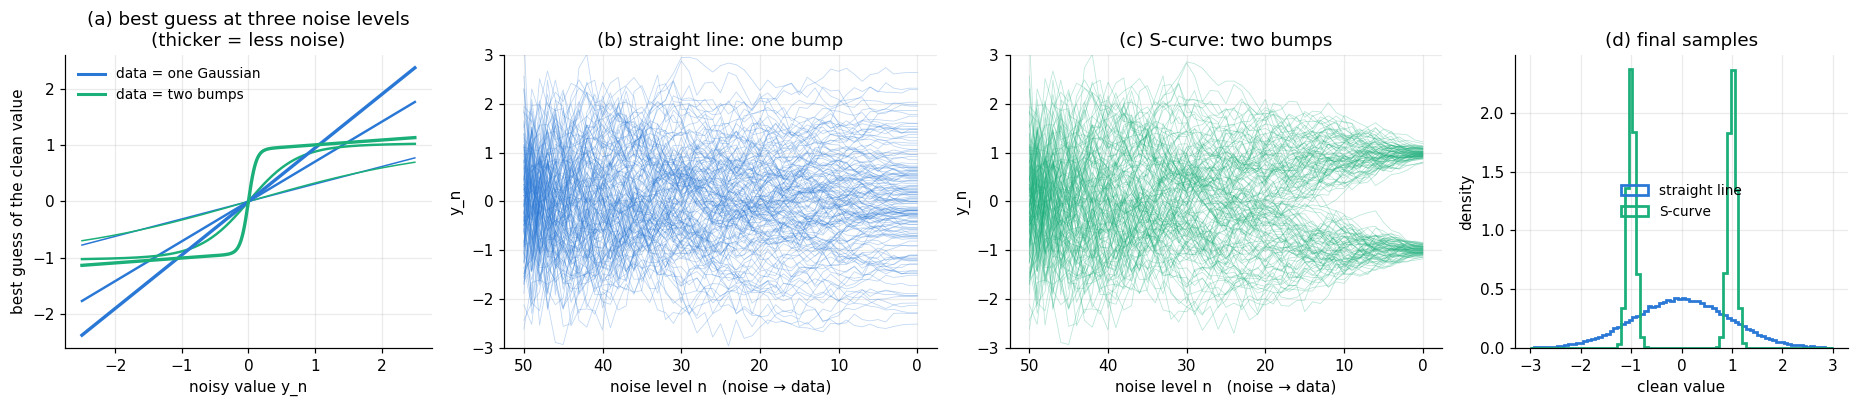

In [5]:
S = 0.1              # width of each bump (as in Part 1)
V = 1.0 + S**2       # variance of the single Gaussian with the same mean and variance


def best_guess_gaussian(y_n, ab):
    """E[y0 | y_n] when the data is N(0, V): a straight line in y_n."""
    return ab.sqrt() * V / (ab * V + 1 - ab) * y_n


def best_guess_two_bumps(y_n, ab):
    """E[y0 | y_n] when the data is two bumps at -1 and +1 (each of width S): an S-curve in y_n."""
    v = ab * S**2 + (1 - ab)                          # variance of y_n around each noised bump
    p_plus = torch.sigmoid(2 * ab.sqrt() * y_n / v)   # probability that y_n came from the +1 bump
    g = ab.sqrt() * S**2 / v
    guess_if_plus  = +1 + g * (y_n - ab.sqrt())
    guess_if_minus = -1 + g * (y_n + ab.sqrt())
    return p_plus * guess_if_plus + (1 - p_plus) * guess_if_minus


def sample_without_network(best_guess, n_samples=100_000, n_keep=150, seed=0):
    """The reverse process, with a formula in the place where the network will be later."""
    torch.manual_seed(seed)
    y = torch.randn(n_samples)                        # start: pure noise at n = N
    path = [y[:n_keep].clone()]                       # remember a few samples for plotting
    for n in range(N_STEPS, 0, -1):                   # n = N, N-1, ..., 1
        ab, ab_prev = alphabar[n], alphabar[n - 1]
        beta_n = 1 - ab / ab_prev
        y0_hat = best_guess(y, ab)                    # the guess of the clean value
        mean = (ab_prev.sqrt() * beta_n / (1 - ab)) * y0_hat \
             + ((1 - beta_n).sqrt() * (1 - ab_prev) / (1 - ab)) * y
        var = beta_n * (1 - ab_prev) / (1 - ab)
        if n > 1:
            y = mean + var.sqrt() * torch.randn_like(y)   # a small Gaussian step
        else:
            y = mean                                      # last step: no noise
        path.append(y[:n_keep].clone())
    return y, torch.stack(path)


y_line, path_line = sample_without_network(best_guess_gaussian)
y_curve, path_curve = sample_without_network(best_guess_two_bumps)

for name, y in [("straight-line denoiser", y_line), ("S-curve denoiser", y_curve)]:
    middle = (y.abs() < 0.5).float().mean()
    print(f"{name:24s} mean {y.mean():+.2f}   variance {y.var():.2f}   share with |y| < 0.5: {middle:.1%}")

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), gridspec_kw={"width_ratios": [1.1, 1.3, 1.3, 1]})

# (a) the two denoisers at three noise levels: high, medium and low noise
y_grid = torch.linspace(-2.5, 2.5, 300)
for n, lw in [(4 * N_STEPS // 5, 1.0), (N_STEPS // 2, 1.6), (N_STEPS // 5, 2.2)]:
    axes[0].plot(y_grid, best_guess_gaussian(y_grid, alphabar[n]), color=C_GAUSS, lw=lw)
    axes[0].plot(y_grid, best_guess_two_bumps(y_grid, alphabar[n]), color=C_DIFF, lw=lw)
axes[0].plot([], [], color=C_GAUSS, lw=2, label="data = one Gaussian")
axes[0].plot([], [], color=C_DIFF, lw=2, label="data = two bumps")
axes[0].set_title("(a) best guess at three noise levels\n(thicker = less noise)")
axes[0].set_xlabel("noisy value y_n")
axes[0].set_ylabel("best guess of the clean value")
axes[0].set_ylim(-2.6, 2.6)
axes[0].legend(loc="upper left")

# (b), (c) paths of a few samples from noise (left) to data (right)
levels = np.arange(N_STEPS, -1, -1)
for ax, path, color, title in [(axes[1], path_line, C_GAUSS, "(b) straight line: one bump"),
                               (axes[2], path_curve, C_DIFF, "(c) S-curve: two bumps")]:
    ax.plot(levels, path.numpy(), color=color, lw=0.5, alpha=0.3)
    ax.invert_xaxis()
    ax.set_ylim(-3, 3)
    ax.set_title(title)
    ax.set_xlabel("noise level n   (noise → data)")
    ax.set_ylabel("y_n")

# (d) the final samples
bins = np.linspace(-3, 3, 81)
axes[3].hist(y_line.numpy(), bins, density=True, histtype="step", lw=1.8, color=C_GAUSS, label="straight line")
axes[3].hist(y_curve.numpy(), bins, density=True, histtype="step", lw=1.8, color=C_DIFF, label="S-curve")
axes[3].set_title("(d) final samples")
axes[3].set_xlabel("clean value")
axes[3].set_ylabel("density")
axes[3].legend(loc="center")

show("fig4_no_network")

The same noise and the same sampler give one bump with the straight line and two bumps with the S-curve. This is the link between the two kinds of head: **a Gaussian head is a diffusion head whose denoiser is a straight line**, and everything beyond that lives in the curvature of the denoiser. (The straight-line run ends with a variance of about 0.92 instead of 1.01. This small error comes from using only 50 steps and disappears with more steps.)

# Part 3 — Our first diffusion model

In real problems we have no formula for the best guess, so a small neural network has to learn it. This network is the **diffusion head**. It receives three inputs:

1. the noisy value $y_n$ (one number);
2. the noise level $n$, turned into a vector of 16 numbers by an embedding, so that the network knows how noisy its input is;
3. a summary $\mathbf{h}$ of the context (32 numbers). We will need it in Part 5, and until then we simply feed zeros.

It outputs one number, its prediction of the noise that was added.

**The loss** is the training loop of the article (Section 6, Step 4) in code: pick a random noise level, draw a noise, add it with the jump formula, ask the network which noise was added, and take the squared error. One small trick makes training smoother, which is that every example is reused with 8 different noise draws (`n_draws = 8`).

**Sampling** (article, Section 8) is the same loop as in the previous cell, with the network in the place of the formula. Since the network predicts the noise, we first convert its answer into a guess of the clean value, $\hat y_0 = (y_n - \sqrt{1 - \bar\alpha_n}\;\hat\varepsilon)/\sqrt{\bar\alpha_n}$, and we clamp that guess to the range $[-3, 3]$ to keep the first, very noisy steps stable.


In [6]:
D_H = 32     # size of the context summary h


class DiffusionHead(nn.Module):
    """A small diffusion model for ONE number, guided by a context summary h."""

    def __init__(self, d_h=D_H, hidden=128, n_draws=8):
        super().__init__()
        self.n_draws = n_draws                                       # noise draws per training example
        self.register_buffer("alphabar", cosine_alphabar(N_STEPS))   # the schedule: fixed, not learned
        self.step_embed = nn.Embedding(N_STEPS + 1, 16)              # one vector of 16 numbers per noise level
        self.net = nn.Sequential(                                    # the denoising network
            nn.Linear(1 + 16 + d_h, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def predict_noise(self, y_n, n, h):
        """y_n: (B, 1) noisy values, n: (B,) noise levels, h: (B, d_h) context summaries -> (B, 1)."""
        inputs = torch.cat([y_n, self.step_embed(n), h], dim=-1)
        return self.net(inputs)

    def loss(self, h, y0):
        """h: (B, d_h), y0: (B, 1) clean values. Returns the MSE between the true and the predicted noise."""
        h = h.repeat(self.n_draws, 1)                    # reuse every example n_draws times
        y0 = y0.repeat(self.n_draws, 1)
        n = torch.randint(1, N_STEPS + 1, (len(y0),))    # a random noise level in 1 .. N for every row
        ab = self.alphabar[n].unsqueeze(-1)
        eps = torch.randn_like(y0)
        y_n = ab.sqrt() * y0 + (1 - ab).sqrt() * eps     # the jump formula
        eps_hat = self.predict_noise(y_n, n, h)
        return ((eps - eps_hat) ** 2).sum(dim=-1).mean()

    @torch.no_grad()
    def sample(self, h):
        """Draw one sample per row of h, by running the reverse process. Returns (B, 1)."""
        B = h.shape[0]
        y = torch.randn(B, 1)                            # start: pure noise at n = N
        for n in range(N_STEPS, 0, -1):                  # n = N, N-1, ..., 1
            ab, ab_prev = self.alphabar[n], self.alphabar[n - 1]
            beta_n = 1 - ab / ab_prev
            eps_hat = self.predict_noise(y, torch.full((B,), n), h)
            # the network's guess of the clean value
            y0_hat = ((y - (1 - ab).sqrt() * eps_hat) / ab.sqrt()).clamp(-3, 3)
            # mean and variance of the small reverse step
            mean = (ab_prev.sqrt() * beta_n / (1 - ab)) * y0_hat \
                 + ((1 - beta_n).sqrt() * (1 - ab_prev) / (1 - ab)) * y
            var = beta_n * (1 - ab_prev) / (1 - ab)
            if n > 1:
                y = mean + var.sqrt() * torch.randn_like(y)
            else:
                y = mean                                 # last step: no noise
        return y

### Training it on the two bumps of Part 1

Before we attach this head to a forecaster, let's check that it works on the simplest possible problem, which is to generate the two-bump data of Part 1, with no context at all. The training loop below is the standard PyTorch loop: compute the loss on a random mini-batch, backpropagate, and update the weights. It takes a few seconds.

step  500   loss 0.398
step 1000   loss 0.306
step 1500   loss 0.284
step 2000   loss 0.262
share of generated values with |y| < 0.5: 0.2%   (the best Gaussian head had about 38 %)


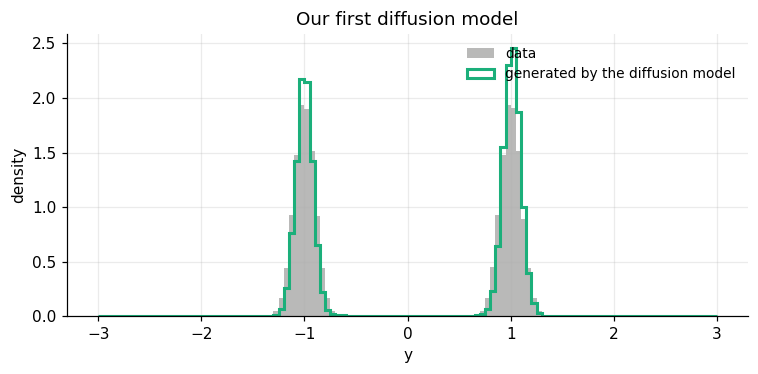

In [7]:
torch.manual_seed(SEED)

toy_data = torch.tensor(y_two_bumps, dtype=torch.float32).unsqueeze(-1)    # (100000, 1): the data of Part 1
toy_head = DiffusionHead()
optimizer = torch.optim.Adam(toy_head.parameters(), lr=2e-3)

BATCH = 256
no_context = torch.zeros(BATCH, D_H)          # there is no context yet, so h is just zeros

for step in range(1, 2001):
    rows = torch.randint(0, len(toy_data), (BATCH,))      # a random mini-batch
    loss = toy_head.loss(no_context, toy_data[rows])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 500 == 0:
        print(f"step {step:4d}   loss {loss.item():.3f}")

# Generate 20,000 new values: start from noise and denoise in N_STEPS steps.
toy_samples = toy_head.sample(torch.zeros(20_000, D_H)).flatten()
middle = (toy_samples.abs() < 0.5).float().mean()
print(f"share of generated values with |y| < 0.5: {middle:.1%}   (the best Gaussian head had about 38 %)")

plt.figure(figsize=(7, 3.5))
bins = np.linspace(-3, 3, 121)
plt.hist(y_two_bumps, bins, density=True, color=C_TRUE, alpha=0.4, label="data")
plt.hist(toy_samples.numpy(), bins, density=True, histtype="step", lw=2, color=C_DIFF, label="generated by the diffusion model")
plt.xlabel("y")
plt.ylabel("density")
plt.title("Our first diffusion model")
plt.legend()
show("fig5_first_diffusion")

The generated values should form two bumps around $-1$ and $+1$, with almost nothing in between. The model was trained with nothing but MSE, and it has learned a shape that no single Gaussian can express.

The theory is now complete, and we can turn to a real forecasting problem.

# Part 4 — The dataset: a ball in a landscape with two wells

A ball rolls in a landscape $V(x) = x^4/4 - x^2/2$, which has two wells at $x = -1$ and $x = +1$ and a small hill, the **barrier**, at $x = 0$. The force $x - x^3$ pushes the ball towards the nearest well, and random kicks jiggle it around and occasionally carry it over the barrier.

One small physics step is

$$x \leftarrow x + \Delta t\,(x - x^3) + s\,\sqrt{\Delta t}\;\xi, \qquad \xi \sim \mathcal{N}(0, 1)$$

and the sensor records one reading every 100 physics steps, so a lot can happen between two readings.

In the code below, `simulate` runs the physics for many balls at once, and `make_dataset` starts each ball in a random well and records 48 readings. The first 32 readings are the **context** that the model sees, and the last 16 are the **future** that it has to forecast.


In [8]:
DT                = 0.02   # size of one physics step
STEPS_PER_READING = 100    # physics steps between two sensor readings
NOISE             = 0.5    # strength of the random kicks (s in the formula)

T_CTX   = 32               # readings the model is allowed to see (the context length T)
HORIZON = 16               # readings the model must forecast (the horizon H)
T_TOT   = T_CTX + HORIZON  # 48 readings per series


def simulate(x_start, n_readings, rng):
    """
    Run the physics for many balls in parallel.

    x_start    : array of shape (n,), the starting positions
    n_readings : how many sensor readings to record
    rng        : a numpy random generator
    returns    : array of shape (n, n_readings)
    """
    x = np.array(x_start, dtype=float)
    readings = np.empty((len(x), n_readings))
    for k in range(n_readings):
        for _ in range(STEPS_PER_READING):
            force = x - x**3
            kick  = NOISE * np.sqrt(DT) * rng.standard_normal(len(x))
            x = x + DT * force + kick
        readings[:, k] = x
    return readings


def make_dataset(n_series, seed):
    """n_series independent series of length T_TOT, each starting in a random well."""
    rng = np.random.default_rng(seed)
    x_start = rng.choice([-1.0, 1.0], size=n_series)
    series = simulate(x_start, T_TOT, rng)
    return torch.tensor(series, dtype=torch.float32)          # (n_series, T_TOT)


X_train = make_dataset(20000, seed=0)
X_val   = make_dataset(1000, seed=1)
X_test  = make_dataset(1000, seed=2)

# For the test series: what the model sees, and what really happened afterwards.
ctx_test = X_test[:, :T_CTX]     # (1000, 32)
fut_test = X_test[:, T_CTX:]     # (1000, 16)

print("training series:", tuple(X_train.shape))
print(f"mean of all values = {X_train.mean():.3f}   standard deviation = {X_train.std():.3f}")

training series: (20000, 48)
mean of all values = 0.005   standard deviation = 0.921


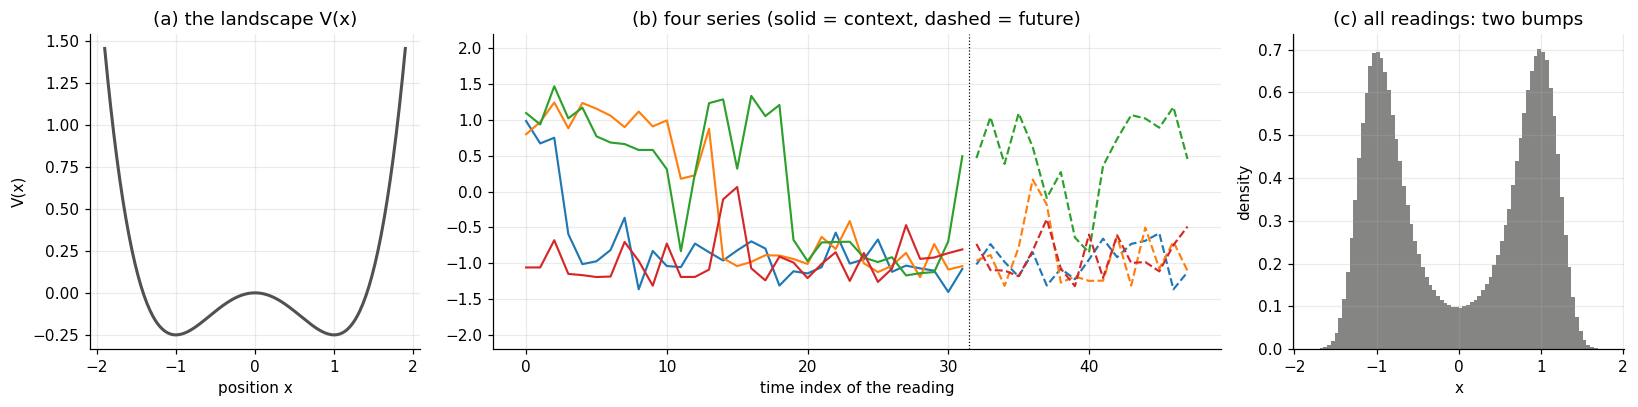

In [9]:
t_ctx = np.arange(T_CTX)            # time index of the context readings: 0 .. 31
t_fut = np.arange(T_CTX, T_TOT)     # time index of the future readings: 32 .. 47

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), gridspec_kw={"width_ratios": [1, 2.2, 1]})

# (a) the landscape V(x) = x^4/4 - x^2/2
xs = np.linspace(-1.9, 1.9, 200)
axes[0].plot(xs, xs**4 / 4 - xs**2 / 2, color=C_TRUE, lw=2)
axes[0].set_title("(a) the landscape V(x)")
axes[0].set_xlabel("position x")
axes[0].set_ylabel("V(x)")

# (b) four complete series: context (solid) and future (dashed)
for i in range(4):
    line, = axes[1].plot(t_ctx, X_train[i, :T_CTX], lw=1.4)
    axes[1].plot(t_fut, X_train[i, T_CTX:], lw=1.4, ls="--", color=line.get_color())
axes[1].axvline(T_CTX - 0.5, color="black", lw=0.8, ls=":")
axes[1].set_title("(b) four series (solid = context, dashed = future)")
axes[1].set_xlabel("time index of the reading")
axes[1].set_ylim(-2.2, 2.2)

# (c) histogram of every value in the training set
axes[2].hist(X_train.flatten().numpy(), bins=80, density=True, color=C_TRUE, alpha=0.7)
axes[2].set_title("(c) all readings: two bumps")
axes[2].set_xlabel("x")
axes[2].set_ylabel("density")

show("fig6_double_well")

The series wiggle inside one well for a while and jump to the other well from time to time, and the histogram of all readings has two bumps with a thin region around the barrier in between.

### The true distribution of futures

This dataset has a property that is rare in forecasting, which is that we know the true answer. The physics has no memory, since where the ball goes next depends only on where it is now. So for any context we can restart the simulator from its last reading as many times as we like, and every restart gives one sample of the **true** future. This is the "repeat the same situation a thousand times" of the article (Section 1.1) made real, and we will use these true futures as the yardstick for every model.

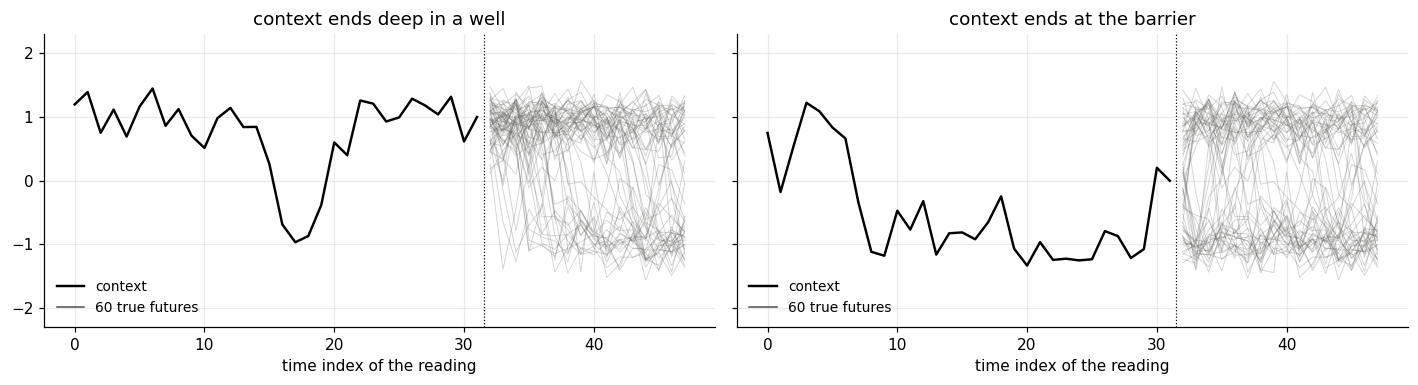

In [10]:
def true_futures(ctx, n_samples, seed=123):
    """
    Draw futures from the true physics, by restarting the simulator from the last reading.

    ctx     : (B, T_CTX) contexts
    returns : (B, n_samples, HORIZON)
    """
    rng = np.random.default_rng(seed)
    last = ctx[:, -1].numpy()
    start = np.repeat(last, n_samples)                 # every context n_samples times
    fut = simulate(start, HORIZON, rng)
    return torch.tensor(fut, dtype=torch.float32).view(len(ctx), n_samples, HORIZON)


# Pick two test contexts: one that ends deep in a well, and one that ends at the barrier.
last = ctx_test[:, -1]
i_deep = int(torch.argmin((last - 1.0).abs()))     # last reading closest to +1
i_edge = int(torch.argmin(last.abs()))             # last reading closest to 0

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, i, title in [(axes[0], i_deep, "context ends deep in a well"),
                     (axes[1], i_edge, "context ends at the barrier")]:
    futures = true_futures(ctx_test[i:i + 1], 60)[0]            # (60, HORIZON)
    ax.plot(t_ctx, ctx_test[i], color="black", lw=1.6, label="context")
    for s in range(60):
        ax.plot(t_fut, futures[s], color=C_TRUE, lw=0.6, alpha=0.25)
    ax.plot([], [], color=C_TRUE, lw=1, label="60 true futures")
    ax.axvline(T_CTX - 0.5, color="black", lw=0.8, ls=":")
    ax.set_title(title)
    ax.set_xlabel("time index of the reading")
    ax.legend(loc="lower left")
axes[0].set_ylim(-2.3, 2.3)

show("fig7_true_futures")

When the context ends deep in a well, the futures stay together at first and slowly grow a second branch. When it ends at the barrier, they split into two branches immediately, which is exactly the two-bump situation of Part 1.

# Part 5 — Two forecasters that differ only in their head

Now we connect the head to the forecasting problem. Both forecasters have the same two parts:

```
context (32 readings)  -->  ENCODER  -->  h (32 numbers)  -->  HEAD  -->  a sample of the next reading
```

* **The encoder** is a small multilayer perceptron that turns the 32 readings of the context into the summary `h`. (Parts I and II used a transformer here. The heads work unchanged with either, and the perceptron trains much faster on a CPU.)
* **The Gaussian head** is the model of Parts I and II: it predicts a mean and a log-variance and is trained with the Gaussian NLL. It draws a sample with `mu + sigma * noise`.
* **The diffusion head** is the class we trained in notebook Part 3 (above). The only change is that it now receives a real `h` instead of zeros.

Both heads offer the same two methods, `loss(h, y)` and `sample(h)`, so the rest of the code does not need to know which one it is talking to.


In [11]:
class Encoder(nn.Module):
    """Turns a context of T_CTX readings into a summary vector h."""

    def __init__(self, d_h=D_H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(T_CTX, 64), nn.SiLU(),
            nn.Linear(64, 64), nn.SiLU(),
            nn.Linear(64, d_h),
        )

    def forward(self, ctx):          # ctx: (B, T_CTX)
        return self.net(ctx)         # h  : (B, d_h)


class GaussianHead(nn.Module):
    """The head of Parts I and II: the next value is N(mu(h), sigma(h)^2)."""

    def __init__(self, d_h=D_H):
        super().__init__()
        self.mu_layer = nn.Linear(d_h, 1)       # predicts the mean
        self.lv_layer = nn.Linear(d_h, 1)       # predicts log(sigma^2)

    def loss(self, h, y):
        mu = self.mu_layer(h)
        lv = self.lv_layer(h).clamp(-7, 3)      # keeps sigma between about 0.03 and 4.5
        nll = 0.5 * (math.log(2 * math.pi) + lv + (y - mu) ** 2 / lv.exp())    # Gaussian NLL
        return nll.sum(dim=-1).mean()

    @torch.no_grad()
    def sample(self, h):
        mu = self.mu_layer(h)
        sigma = (0.5 * self.lv_layer(h).clamp(-7, 3)).exp()
        return mu + sigma * torch.randn_like(mu)


class Forecaster(nn.Module):
    """encoder (context -> h)  followed by  head (h -> distribution of the next reading)."""

    def __init__(self, head):
        super().__init__()
        self.encoder = Encoder()
        self.head = head

    def loss(self, ctx, y):
        return self.head.loss(self.encoder(ctx), y)

    @torch.no_grad()
    def sample(self, ctx):
        return self.head.sample(self.encoder(ctx))

### Training data and training loop

As in Part II, the model forecasts **one reading at a time**. We therefore cut every training series into pairs of (a window of 32 readings, the reading right after it). Each series of 48 readings gives 16 such pairs, so the 20,000 series give 320,000 training pairs.

The function `train_model` is an ordinary training loop that works for both forecasters, because both offer the same `loss` method. It uses three standard ingredients:

* **AdamW**, the usual optimiser;
* a **learning rate that decreases** smoothly during training (large steps first, small steps at the end);
* **gradient clipping**, which keeps a single unlucky mini-batch from throwing the weights far away.

After every epoch it also computes the loss on the validation series, which the model never trains on.

In [12]:
def one_step_pairs(X):
    """Cut every series into (window of T_CTX readings, the next reading) pairs."""
    windows = [X[:, k:k + T_CTX] for k in range(HORIZON)]
    targets = [X[:, k + T_CTX:k + T_CTX + 1] for k in range(HORIZON)]
    return torch.cat(windows), torch.cat(targets)        # (n_pairs, T_CTX), (n_pairs, 1)


win_train, y_train = one_step_pairs(X_train)
win_val,   y_val   = one_step_pairs(X_val)
print("training pairs:", tuple(win_train.shape), tuple(y_train.shape))


def train_model(model, name, epochs=15, batch=1024, lr=2e-3):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr / 20)
    start = time.time()
    for ep in range(1, epochs + 1):
        # --- one pass over the training pairs, in random order ---
        model.train()
        perm = torch.randperm(len(win_train))
        total = 0.0
        for i in range(0, len(win_train), batch):
            b = perm[i:i + batch]                               # the rows of this mini-batch
            loss = model.loss(win_train[b], y_train[b])
            opt.zero_grad()                                     # clear the old gradients
            loss.backward()                                     # compute the new gradients
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()                                          # update the weights
            total += loss.item() * len(b)
        sched.step()                                            # lower the learning rate a little
        # --- check on the validation pairs ---
        model.eval()
        with torch.no_grad():
            val = model.loss(win_val, y_val).item()
        if ep == 1 or ep % 5 == 0:
            print(f"  [{name}] epoch {ep:2d}/{epochs}   train loss {total / len(win_train):.3f}   validation loss {val:.3f}")
    print(f"  [{name}] done in {time.time() - start:.0f} s")

training pairs: (320000, 32) (320000, 1)


In [13]:
# The two forecasters are identical except for the head.
# The seed is reset before each one, so that both start from the same kind of random weights.

torch.manual_seed(SEED)
gauss_model = Forecaster(GaussianHead())
train_model(gauss_model, "Gaussian head")

torch.manual_seed(SEED)
diff_model = Forecaster(DiffusionHead())
train_model(diff_model, "diffusion head")

  [Gaussian head] epoch  1/15   train loss 0.685   validation loss 0.619
  [Gaussian head] epoch  5/15   train loss 0.574   validation loss 0.570
  [Gaussian head] epoch 10/15   train loss 0.565   validation loss 0.566
  [Gaussian head] epoch 15/15   train loss 0.562   validation loss 0.564
  [Gaussian head] done in 29 s
  [diffusion head] epoch  1/15   train loss 0.344   validation loss 0.300
  [diffusion head] epoch  5/15   train loss 0.263   validation loss 0.264
  [diffusion head] epoch 10/15   train loss 0.261   validation loss 0.261
  [diffusion head] epoch 15/15   train loss 0.259   validation loss 0.263
  [diffusion head] done in 59 s


The two losses cannot be compared with each other, because one is a negative log-likelihood and the other is a squared error on the noise. We will compare the models properly in Part 6, through the forecasts they produce.

# Part 6 — Rolling out, and comparing with the truth

### The sampled rollout of Part II

`rollout` is the recipe of Part II in a few lines: ask the model for **one sample** of the next reading, store it, slide the window by one reading (the oldest reading drops out and the new sample enters), and repeat. To get $M = 100$ trajectories per context, we simply repeat every context 100 times, and each copy follows its own random path.

For the Gaussian head, one sample is a single line of code. For the diffusion head, one sample means running the reverse process with its 50 denoising steps, so a trajectory of 16 readings costs $16 \times 50 = 800$ small network calls. This cell is therefore the slowest one in the notebook — typically one to two minutes on a laptop CPU.


In [14]:
@torch.no_grad()
def rollout(model, ctx, n_steps=HORIZON):
    """Sampled autoregressive rollout: draw one reading, append it, slide the window, repeat."""
    window = ctx.clone()
    future = []
    for _ in range(n_steps):
        nxt = model.sample(window)                         # (B, 1): a SAMPLE, not the mean (Part II)
        future.append(nxt)
        window = torch.cat([window[:, 1:], nxt], dim=1)    # drop the oldest reading, add the new one
    return torch.cat(future, dim=1)                        # (B, n_steps)


M = 100                                                    # trajectories per test context

torch.manual_seed(1)
ctx_repeated = ctx_test.repeat_interleave(M, 0)            # every test context M times: (100000, 32)

start = time.time()
paths_gauss = rollout(gauss_model, ctx_repeated).view(len(ctx_test), M, HORIZON)
print(f"Gaussian head : {M} rollouts for each of {len(ctx_test)} contexts in {time.time() - start:.0f} s")

start = time.time()
paths_diff = rollout(diff_model, ctx_repeated).view(len(ctx_test), M, HORIZON)
print(f"diffusion head: {M} rollouts for each of {len(ctx_test)} contexts in {time.time() - start:.0f} s")

# The same number of futures from the true physics: the best any model could possibly do.
paths_true = true_futures(ctx_test, M)

print("shape of each set of paths:", tuple(paths_diff.shape), "= (contexts, trajectories, horizon)")

Gaussian head : 100 rollouts for each of 1000 contexts in 0 s
diffusion head: 100 rollouts for each of 1000 contexts in 59 s
shape of each set of paths: (1000, 100, 16) = (contexts, trajectories, horizon)


### Looking at the forecasts

Before computing any score, let's look. We take the test context that ends at the barrier (the hardest case) and compare three things: the distribution of the **very next reading** according to the true physics and to each model, and 25 rollouts from each model.

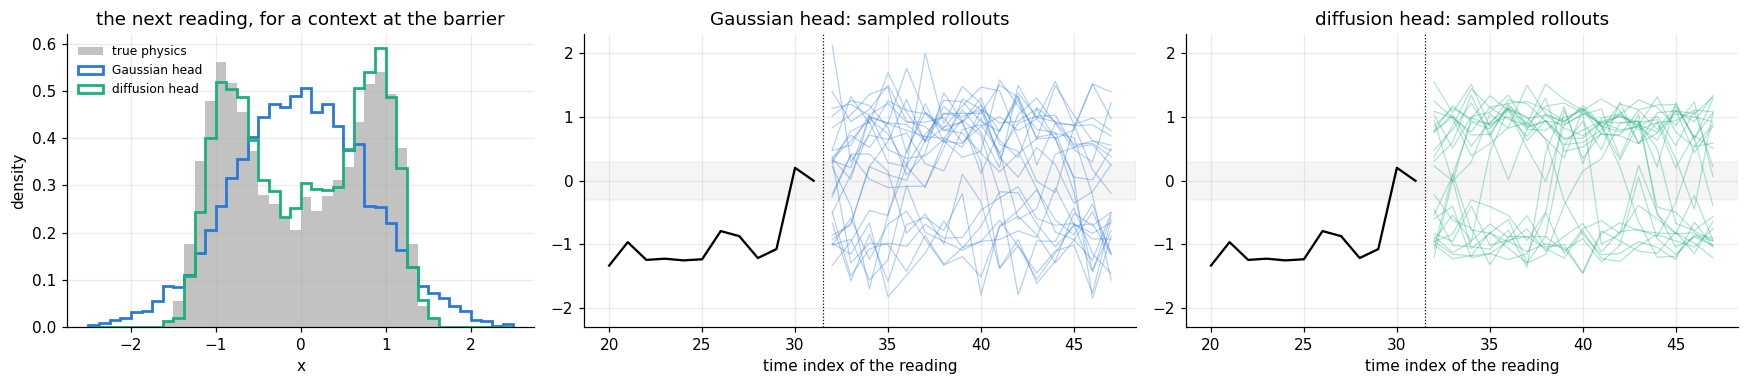

In [15]:
torch.manual_seed(3)

# 5,000 samples of the very next reading, for the context that ends at the barrier.
barrier_ctx = ctx_test[i_edge:i_edge + 1].repeat(5000, 1)                 # (5000, 32)
next_gauss = gauss_model.sample(barrier_ctx).flatten()
next_diff  = diff_model.sample(barrier_ctx).flatten()
next_true  = true_futures(ctx_test[i_edge:i_edge + 1], 5000)[0][:, 0]     # first reading of 5,000 true futures

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6), gridspec_kw={"width_ratios": [1.1, 1.3, 1.3]})

# left: the distribution of the next reading
bins = np.linspace(-2.5, 2.5, 41)
axes[0].hist(next_true.numpy(), bins, density=True, color=C_TRUE, alpha=0.35, label="true physics")
axes[0].hist(next_gauss.numpy(), bins, density=True, histtype="step", lw=1.8, color=C_GAUSS, label="Gaussian head")
axes[0].hist(next_diff.numpy(), bins, density=True, histtype="step", lw=1.8, color=C_DIFF, label="diffusion head")
axes[0].set_title("the next reading, for a context at the barrier")
axes[0].set_xlabel("x")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)

# middle and right: 25 rollouts from each model
for ax, paths, color, title in [(axes[1], paths_gauss, C_GAUSS, "Gaussian head: sampled rollouts"),
                                (axes[2], paths_diff, C_DIFF, "diffusion head: sampled rollouts")]:
    ax.plot(t_ctx[-12:], ctx_test[i_edge, -12:], color="black", lw=1.5)   # the end of the context
    for s in range(25):
        ax.plot(t_fut, paths[i_edge, s], color=color, lw=0.8, alpha=0.35)
    ax.axvline(T_CTX - 0.5, color="black", lw=0.8, ls=":")
    ax.axhspan(-0.3, 0.3, color="grey", alpha=0.08)                       # the barrier region
    ax.set_title(title)
    ax.set_xlabel("time index of the reading")
    ax.set_ylim(-2.3, 2.3)

show("fig8_forecasts")

In the left panel, the true distribution of the next reading has two bumps. The Gaussian head can only offer one broad bump, with its peak where the truth has a dip, while the diffusion head reproduces both bumps. In the rollouts, many Gaussian paths start inside the shaded barrier region, whereas the diffusion paths leave it at once and commit to a well, as the real ball does.

### Putting numbers on it

We use three measures (article, Section 10):

* **CRPS** $= \mathbb{E}|X - y| - \tfrac12\,\mathbb{E}|X - X'|$, where $X$ and $X'$ are forecast samples and $y$ is what really happened. The first term rewards samples that are close to the truth, and the second gives credit back for honest spread. Lower is better.
* **Barrier share**: the fraction of forecast values that fall into the region $|x| < 0.3$ around the barrier, where the real ball spends very little time.
* **Distance to the true distribution**: sort the samples of the model and the samples of the true physics, and average the gaps between them. Two independent sets of true samples do not give exactly zero, because they are finite, so we also print this "truth against truth" value as the best a model could reach.

We report the scores over all 1,000 test contexts and, separately, over the contexts that end near the barrier ($|\text{last reading}| < 0.5$), where the shape matters most.

In [16]:
def crps(paths, truth):
    """
    paths : (B, M, H) forecast samples,   truth : (B, H) what really happened.
    Returns one CRPS value per context, shape (B,), averaged over the H future readings.
    """
    n_samples = paths.shape[1]
    scores = []
    for p, y in zip(paths, truth):                           # p: (M, H) samples of one context, y: (H,)
        accuracy = (p - y).abs().mean(dim=0)                 # E|X - y|   for every future reading
        pairs = (p.unsqueeze(0) - p.unsqueeze(1)).abs()      # |X - X'|   for all pairs of samples: (M, M, H)
        spread = pairs.sum(dim=(0, 1)) / (n_samples * (n_samples - 1))    # average over pairs of different samples
        scores.append((accuracy - 0.5 * spread).mean())
    return torch.stack(scores)


def barrier_share(paths):
    """Fraction of forecast values inside the barrier region |x| < 0.3."""
    return (paths.abs() < 0.3).float().mean().item()


def distance_to_truth(paths, true_paths):
    """Sort both sets of samples and average the gaps between them -> (B, H)."""
    return (paths.sort(dim=1).values - true_paths.sort(dim=1).values).abs().mean(dim=1)


near = ctx_test[:, -1].abs() < 0.5          # the test contexts that end near the barrier
print(f"{int(near.sum())} of {len(ctx_test)} test contexts end near the barrier\n")

models = [("true physics", paths_true), ("Gaussian head", paths_gauss), ("diffusion head", paths_diff)]

# --- Table 1: CRPS and barrier share ---
crps_true = crps(paths_true, fut_test)
print("model          | CRPS (all)  CRPS (near barrier) | gap to the truth (all)  | barrier share")
for name, paths in models:
    c = crps(paths, fut_test)
    gap = c - crps_true                          # same contexts, same outcomes: a paired comparison
    gap_error = gap.std() / len(gap) ** 0.5      # standard error of the average gap
    print(f"{name:14s} |   {c.mean():.3f}        {c[near].mean():.3f}          | {gap.mean():+.4f} +- {gap_error:.4f}       |   {barrier_share(paths):.3f}")

# --- Table 2: distance to the true distribution ---
paths_true_2 = true_futures(ctx_test, M, seed=999)        # a second, independent set of true futures
print("\nmodel          | distance to truth (all)   (near barrier)   (near barrier, one step ahead)")
for name, paths in [("truth vs truth", paths_true_2), ("Gaussian head", paths_gauss), ("diffusion head", paths_diff)]:
    d = distance_to_truth(paths, paths_true)
    print(f"{name:14s} |        {d.mean():.3f}               {d[near].mean():.3f}              {d[near][:, 0].mean():.3f}")

143 of 1000 test contexts end near the barrier

model          | CRPS (all)  CRPS (near barrier) | gap to the truth (all)  | barrier share
true physics   |   0.428        0.485          | +0.0000 +- 0.0000       |   0.066
Gaussian head  |   0.435        0.494          | +0.0072 +- 0.0017       |   0.128
diffusion head |   0.428        0.493          | -0.0002 +- 0.0019       |   0.058

model          | distance to truth (all)   (near barrier)   (near barrier, one step ahead)
truth vs truth |        0.119               0.131              0.112
Gaussian head  |        0.172               0.185              0.221
diffusion head |        0.128               0.141              0.112


true physics    1 step ahead: 0.116    16 steps ahead: 0.065
Gaussian head   1 step ahead: 0.264    16 steps ahead: 0.127
diffusion head  1 step ahead: 0.120    16 steps ahead: 0.058


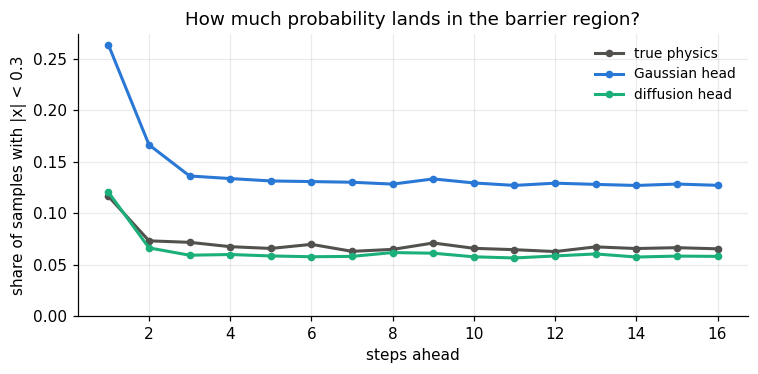

In [17]:
# The barrier share along the forecast horizon, for the contexts that end near the barrier.
horizons = np.arange(1, HORIZON + 1)

plt.figure(figsize=(7, 3.5))
for name, paths, color in [("true physics", paths_true, C_TRUE),
                           ("Gaussian head", paths_gauss, C_GAUSS),
                           ("diffusion head", paths_diff, C_DIFF)]:
    share = (paths[near].abs() < 0.3).float().mean(dim=(0, 1))      # one value per future reading: (H,)
    plt.plot(horizons, share.numpy(), marker="o", ms=4, lw=2, color=color, label=name)
    print(f"{name:14s}  1 step ahead: {share[0]:.3f}    16 steps ahead: {share[-1]:.3f}")
plt.xlabel("steps ahead")
plt.ylabel("share of samples with |x| < 0.3")
plt.title("How much probability lands in the barrier region?")
plt.ylim(0, None)
plt.legend()
show("fig9_barrier_share")

### Reading the results

* **CRPS.** Over all contexts the Gaussian head is a little behind the true physics, and the diffusion head should be on a par with it. Near the barrier the two models score almost the same, even though the figure above shows a difference that is hard to miss.
* **Barrier share.** The Gaussian head puts roughly twice as much probability into the barrier region as the true physics does, and the diffusion head is close to the truth.
* **Distance to the true distribution.** One step ahead near the barrier, the diffusion head should be at the "truth against truth" level, and the Gaussian head about twice as far away.
* **The last figure.** The Gaussian head improves along the horizon, because the sampled rollout of Part II repairs part of the shape, but it starts from a wrong first step and never fully catches up.

The lesson is the one of the whole series in a new form: a single summary number can hide the very thing you care about, so whenever you can, look at the samples.

# What we did, in short

1. A Gaussian head can have the right mean and the right variance and the wrong shape. Several bell curves repair it, and infinitely many bell curves, selected by a hidden variable, can express any shape (notebook Part 1).
2. A diffusion model builds its hidden variables by adding noise with a fixed recipe, and learns to remove the noise in small Gaussian steps. With a straight-line denoiser it can only produce a Gaussian; with a curved one it can produce any shape (notebook Part 2).
3. It is trained with plain MSE on the noise (notebook Part 3).
4. As a head on a forecaster, it slots into the sampled rollout of series Part II without any other change (notebook Parts 4–6).

### Things to try

* Change `mu_of_z` in Part 1 (for example to `z**2` or `np.exp(z / 2)`) and see which shapes a continuous mixture can produce.
* Change `N_STEPS` to 20 or 200 and see how the samples and the run time change.
* Set `n_draws = 1` in `DiffusionHead` and watch what happens to the training.
* Make the kicks stronger or weaker (`NOISE`) and see how the two heads cope.
* Replace `Encoder` by the transformer of Parts I and II. The heads do not need to change.
* Compute the probability of crossing a threshold from the samples, as in Part I, for both heads.
